# 04: The 2026 Restructuring Journey

**Business question**: What exactly happened in January 2026, mechanically, and does the resulting entity's reported financial trend mean what it looks like it means?

## The transaction, mechanically

On **26 July 2024**, AirAsia X Berhad entered a Share Sale and Purchase Agreement with Capital A Berhad to acquire 100% of AirAsia Aviation Group Limited (AAAGL), the entity holding AirAsia's short/medium-haul airlines (Malaysia, Thailand, Indonesia, Philippines, Cambodia). The purchase price was satisfied entirely through shares: **2,307,692,307 new AirAsia X ordinary shares issued to Capital A at RM1.67 per share**, a total consideration of **RM3,853,846,152**. The transaction completed on **16 January 2026**. **[PUBLIC, AirAsia Group Q2 2026 quarterly announcement, Note 1b]**

Under Malaysian Financial Reporting Standard MFRS 3, this was treated as a **reverse acquisition**: although AirAsia X is the legal parent, AAAGL is treated as the accounting acquirer. This is why the consolidated financial statements issued under AirAsia X's (now AirAsia Group's) name are, for accounting purposes, a continuation of AAAGL's own historical financials, not AirAsia X's. **[PUBLIC]**

## The revenue trend that isn't what it looks like

In [1]:
import sqlite3
import pandas as pd
from IPython.display import Image

conn = sqlite3.connect('../data/processed/airasia.db')
df = pd.read_sql('''SELECT q.quarter_id, q.reporting_entity, g.revenue_rm000/1000.0 AS revenue_rm_million
                     FROM quarters q JOIN group_financials g ON q.quarter_id=g.quarter_id
                     ORDER BY q.fiscal_year, q.fiscal_quarter''', conn)
conn.close()

last_standalone = df[df['reporting_entity']=='AirAsia X (standalone)']['revenue_rm_million'].iloc[-1]
first_consolidated = df[df['reporting_entity']=='AirAsia Group (consolidated)']['revenue_rm_million'].iloc[0]
print(f"Last standalone quarter (2025Q4): RM{last_standalone:,.0f}m")
print(f"First consolidated quarter (2026Q1): RM{first_consolidated:,.0f}m")
print(f"Apparent jump: {first_consolidated/last_standalone:.1f}x, this is a change in reporting entity, not organic growth")
df

Last standalone quarter (2025Q4): RM921m
First consolidated quarter (2026Q1): RM5,950m
Apparent jump: 6.5x, this is a change in reporting entity, not organic growth


,quarter_id,reporting_entity,revenue_rm_million
0,2024Q1,AirAsia X (standalone),908.917
1,2024Q2,AirAsia X (standalone),669.141
2,2024Q3,AirAsia X (standalone),795.027
3,2024Q4,AirAsia X (standalone),872.347
4,2025Q1,AirAsia X (standalone),940.084
5,2025Q2,AirAsia X (standalone),660.797
6,2025Q3,AirAsia X (standalone),803.486
7,2025Q4,AirAsia X (standalone),920.810
8,2026Q1,AirAsia Group (consolidated),5950.223
9,2026Q2,AirAsia Group (consolidated),5085.584


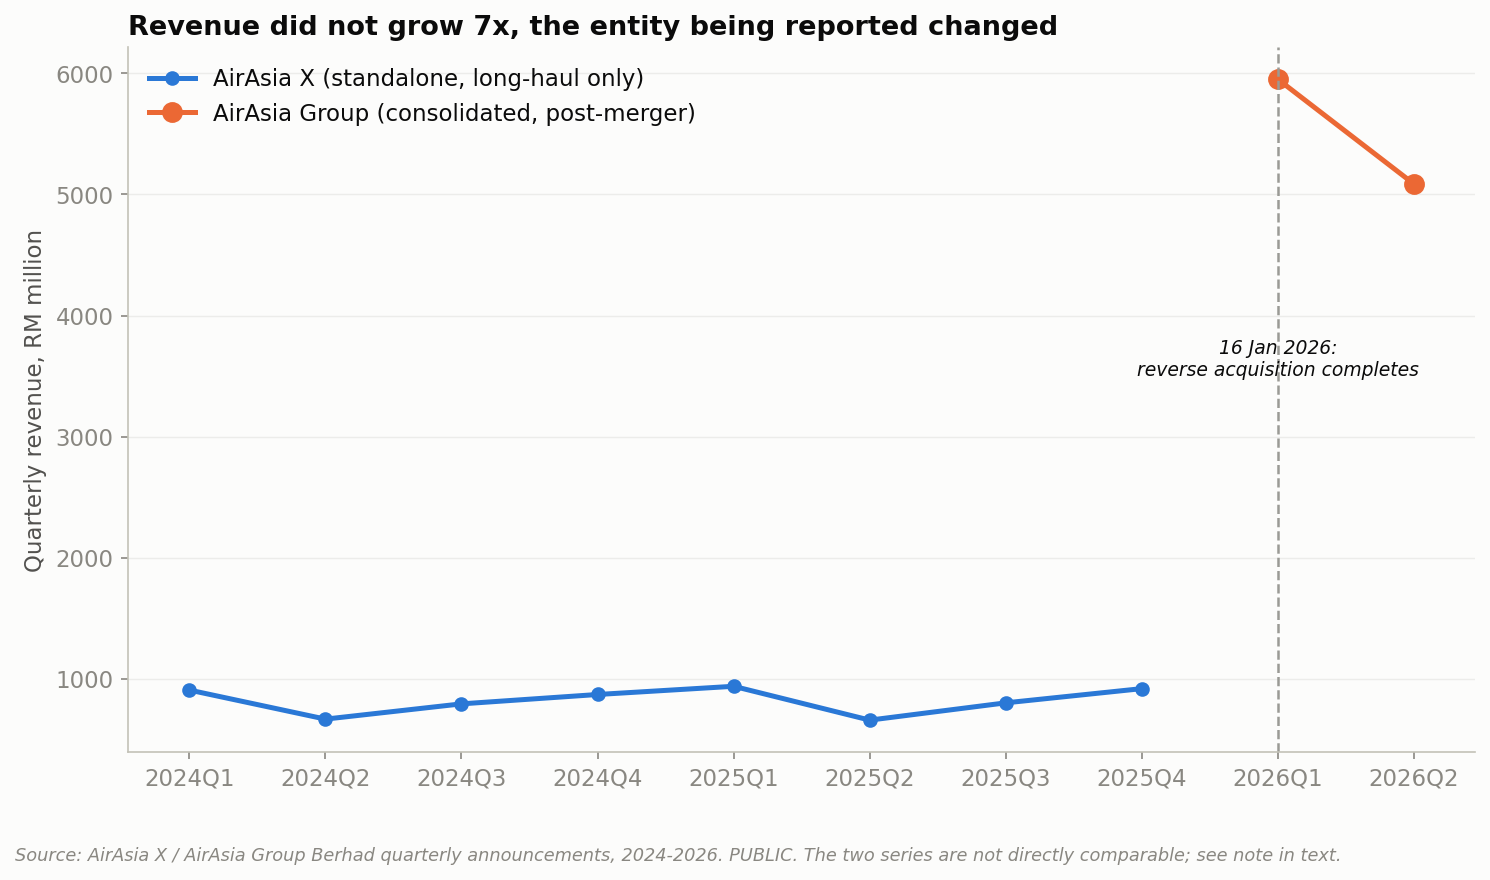

In [2]:
Image(filename='../outputs/figures/04_revenue_discontinuity.png')

Revenue did not grow 6.5x between Q4 2025 and Q1 2026. What changed is which business is being reported: 2024-2025 figures are AirAsia X's standalone long-haul operation only; 2026 figures are the full consolidated group (Malaysia, Thailand, Indonesia, Philippines, Cambodia, plus long-haul). Treating this as one continuous trend line, which several commentary pieces effectively do when they compare 2026 results to "last year," would produce a misleadingly dramatic growth story. Notebook 6's crisis diagnosis relies only on 2026 consolidated-to-consolidated or explicitly pro-forma comparisons, never a naive standalone-to-consolidated one.

## Did the restructuring itself help the balance sheet?

This is a harder question to answer cleanly than it first appears, precisely because of the discontinuity above. What can be said with confidence: AirAsia X entered the merger with **positive shareholders' equity of RM519 million** (Q4 2025, its last standalone quarter), the product of its own multi-year post-restructuring recovery documented in Notebook 3. The combined AirAsia Group's shareholders' equity stood at **RM483 million** as of Q2 2026, similar in scale but now supporting a vastly larger, more complex consolidated balance sheet. Whether that represents dilution of a hard-won recovery or a reasonable trade-off for gaining a full network is a judgment call this notebook does not resolve; Notebook 6 addresses the more urgent question of near-term liquidity directly.

## Explain It Simply

In January 2026, AirAsia's long-haul airline (AirAsia X) formally swallowed the rest of the AirAsia network (Malaysia, Thailand, Indonesia, Philippines, Cambodia) by issuing new shares to Capital A, the old parent company, in exchange for those businesses. This is why AirAsia's reported revenue appears to jump roughly 6-7x overnight starting in 2026: it isn't that the airline suddenly got much bigger by flying more passengers, it's that the accounts started reporting a much bigger combined business instead of just the long-haul piece. Any comparison of "2026 versus 2025" needs to account for this, or it will look far more dramatic, in either direction, than what actually happened operationally.

## Glossary

- **Reverse acquisition**: an accounting treatment (MFRS 3) where the legal acquirer is treated as the accounting acquiree, and vice versa, used when the legal subsidiary is economically the larger or more substantive business.
- **AAAGL**: AirAsia Aviation Group Limited, the entity holding AirAsia's short/medium-haul airline operations, acquired by AirAsia X in this transaction.
- **Consideration shares**: new shares issued as payment for an acquisition, instead of cash.

## Why Is This Happening?

**Why structure this as a reverse acquisition instead of a normal one?** Accounting standards require the entity that is economically dominant, here, AAAGL, the much larger short/medium-haul network, to be treated as the accounting acquirer regardless of which entity is the legal parent. This is not a choice Capital A or AirAsia X made for convenience; it follows directly from MFRS 3's rules once the deal was structured with AirAsia X as the legal issuer of shares. The practical consequence, no restated prior-year comparatives, is a direct, disclosed side effect of this rule, not a gap in reporting.

---
**Sources**: AirAsia Group Berhad Q2 2026 unaudited condensed consolidated financial statements, Notes 1b and 2.1 (investor.airasiagroup.com); AirAsia X / AirAsia Group Q1-Q4 2024, Q1-Q4 2025, Q1-Q2 2026 quarterly announcements. All figures **PUBLIC**, extracted directly from the company's own filed statements.